In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# reading the dataset 
df = pd.read_csv("sales.csv")
df


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [6]:
#find of the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [7]:
# find the statistical information for integer columns
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [8]:
# find the statistical information for string columns
df.describe(include = 'object') # object is of string.

,date,item_name,item_type,transaction_type,received_by,time_of_sale
count,1000,1000,1000,893,1000,1000
unique,348,7,2,2,2,5
top,8/31/2022,Cold coffee,Fastfood,Cash,Mr.,Night
freq,8,161,686,476,512,205


In [9]:
# access column data - for single column
df['item_name']

0             Aalopuri
1              Vadapav
2              Vadapav
3      Sugarcane juice
4      Sugarcane juice
            ...       
995            Frankie
996           Sandwich
997           Sandwich
998           Panipuri
999           Aalopuri
Name: item_name, Length: 1000, dtype: object

In [10]:
# access column data - for multiple columns
df[['item_name','item_type','transaction_type']]

,item_name,item_type,transaction_type
0,Aalopuri,Fastfood,NaN
1,Vadapav,Fastfood,Cash
2,Vadapav,Fastfood,Cash
3,Sugarcane juice,Beverages,Online
4,Sugarcane juice,Beverages,Online
...,...,...,...
995,Frankie,Fastfood,NaN
996,Sandwich,Fastfood,NaN
997,Sandwich,Fastfood,NaN
998,Panipuri,Fastfood,NaN


In [12]:
# to find the unique values in column
df['item_name'].unique() # this op can perform on single column.

array(['Aalopuri', 'Vadapav', 'Sugarcane juice', 'Panipuri', 'Frankie',
       'Sandwich', 'Cold coffee'], dtype=object)

In [13]:
# to find the unique value counts
df['item_name'].value_counts()

item_name
Cold coffee        161
Sugarcane juice    153
Panipuri           150
Frankie            139
Aalopuri           134
Vadapav            134
Sandwich           129
Name: count, dtype: int64

In [14]:
# to find the unique value counts
df['transaction_type'].value_counts()

transaction_type
Cash      476
Online    417
Name: count, dtype: int64

In [15]:
# to find the unique value counts
df['item_type'].value_counts()

item_type
Fastfood     686
Beverages    314
Name: count, dtype: int64

### Dataprocessing


In [16]:
# Handling the missing values
df.isnull()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,True,False,False
996,False,False,False,False,False,False,False,True,False,False
997,False,False,False,False,False,False,False,True,False,False
998,False,False,False,False,False,False,False,True,False,False


In [18]:
# Handling the missing values
# count the null values in each column
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [20]:

df['transaction_type'].mode()

0    Cash
Name: transaction_type, dtype: object

In [23]:
# Handling transaction_type column missing values
df['transaction_type']=df['transaction_type'].fillna('Cash')

In [24]:
df['transaction_type'].isnull().sum()

np.int64(0)

In [25]:
# divide the columns into categeroical and numerical
categorical_columns= ['date','item_name','item_type','transaction_type','received_by','time_of_sale']
numerical_columns= ['order_id','item_price','quantity','transaction_amount']
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

In [27]:
df.drop(['order_id', 'date'],axis=1, inplace=True)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [28]:
# Data Transformation
categorical_columns= ['item_name','item_type','transaction_type','received_by','time_of_sale']


In [29]:
df['item_name'].unique()

array(['Aalopuri', 'Vadapav', 'Sugarcane juice', 'Panipuri', 'Frankie',
       'Sandwich', 'Cold coffee'], dtype=object)

In [34]:
df['item_name'].unique()
item_name_map={'Aalopuri':1, 'Vadapav':2, 'Sugarcane juice':3, 'Panipuri':4, 'Frankie':5,
       'Sandwich':6, 'Cold coffee':7}
df['item_name']= df['item_name'].replace(item_name_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,Fastfood,20,13,260,Cash,Mr.,Night
1,2,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,2,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,3,Beverages,25,6,150,Online,Mr.,Night
4,3,Beverages,25,8,200,Online,Mr.,Evening


In [39]:
df['item_type'].unique()
item_name_map={'Fastfood':1,'Beverages':0}
df['item_type']= df['item_type'].replace(item_name_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,1,20,13,260,1,Mr.,Night
1,2,1,20,15,300,1,Mr.,Afternoon
2,2,1,20,1,20,1,Mr.,Afternoon
3,3,0,25,6,150,2,Mr.,Night
4,3,0,25,8,200,2,Mr.,Evening


In [58]:
df['transaction_type'].unique()
item_name_map={'Cash':1,'Online':2}
df['transaction_type']= df['transaction_type'].replace(item_name_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,1,20,13,260,1,1,4
1,2,1,20,15,300,1,1,2
2,2,1,20,1,20,1,1,2
3,3,0,25,6,150,2,1,4
4,3,0,25,8,200,2,1,3


In [42]:
transaction_type_map={'Online':0,'Cash':1}
received_by_map={'Mrs.':0,'Mr.':1}
time_of_sale_map={'Night':4,'Afternoon':2,'Evening':3,'Morning':1,'Midnight':5}
df['transaction_type']=df['transaction_type'].replace(transaction_type_map)
df['received_by']=df['received_by'].replace(received_by_map)
df['time_of_sale']=df['time_of_sale'].replace(time_of_sale_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,1,20,13,260,1,1,4
1,2,1,20,15,300,1,1,2
2,2,1,20,1,20,1,1,2
3,3,0,25,6,150,2,1,4
4,3,0,25,8,200,2,1,3


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_name           1000 non-null   int64
 1   item_type           1000 non-null   int64
 2   item_price          1000 non-null   int64
 3   quantity            1000 non-null   int64
 4   transaction_amount  1000 non-null   int64
 5   transaction_type    1000 non-null   int64
 6   received_by         1000 non-null   int64
 7   time_of_sale        1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [50]:
categorical_columns 

['item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']

In [51]:
categorical_columns = ['item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']
for col in categorical_columns:
    df[col]=df[col].astype('int32')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_name           1000 non-null   int32
 1   item_type           1000 non-null   int32
 2   item_price          1000 non-null   int64
 3   quantity            1000 non-null   int64
 4   transaction_amount  1000 non-null   int64
 5   transaction_type    1000 non-null   int32
 6   received_by         1000 non-null   int32
 7   time_of_sale        1000 non-null   int32
dtypes: int32(5), int64(3)
memory usage: 43.1 KB


### Data Visualization

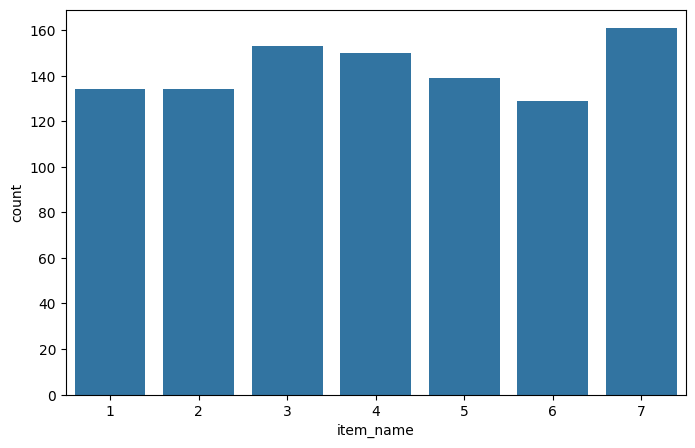

In [53]:
# data visualization
# count plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='item_name')
plt.show()

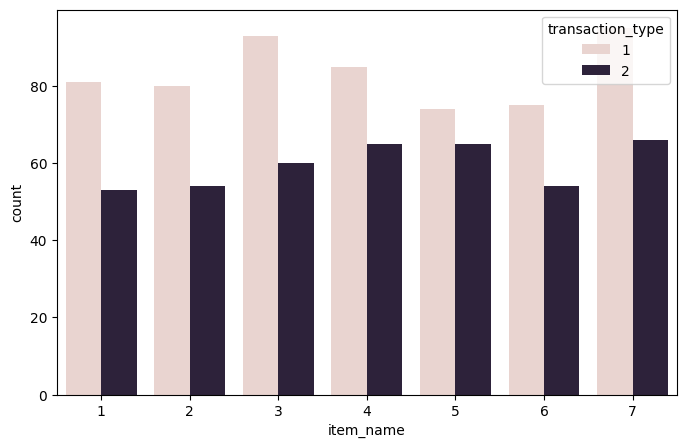

In [54]:
# data visualization
# count plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='item_name', hue='transaction_type')
plt.show()

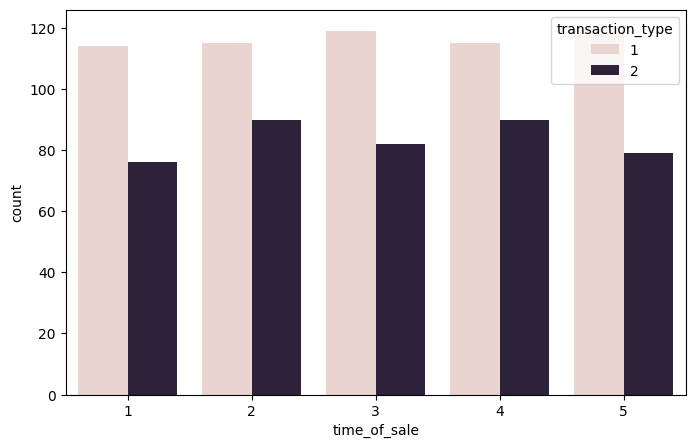

In [59]:
# data visualization
# count plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='time_of_sale', hue='transaction_type')
plt.show()

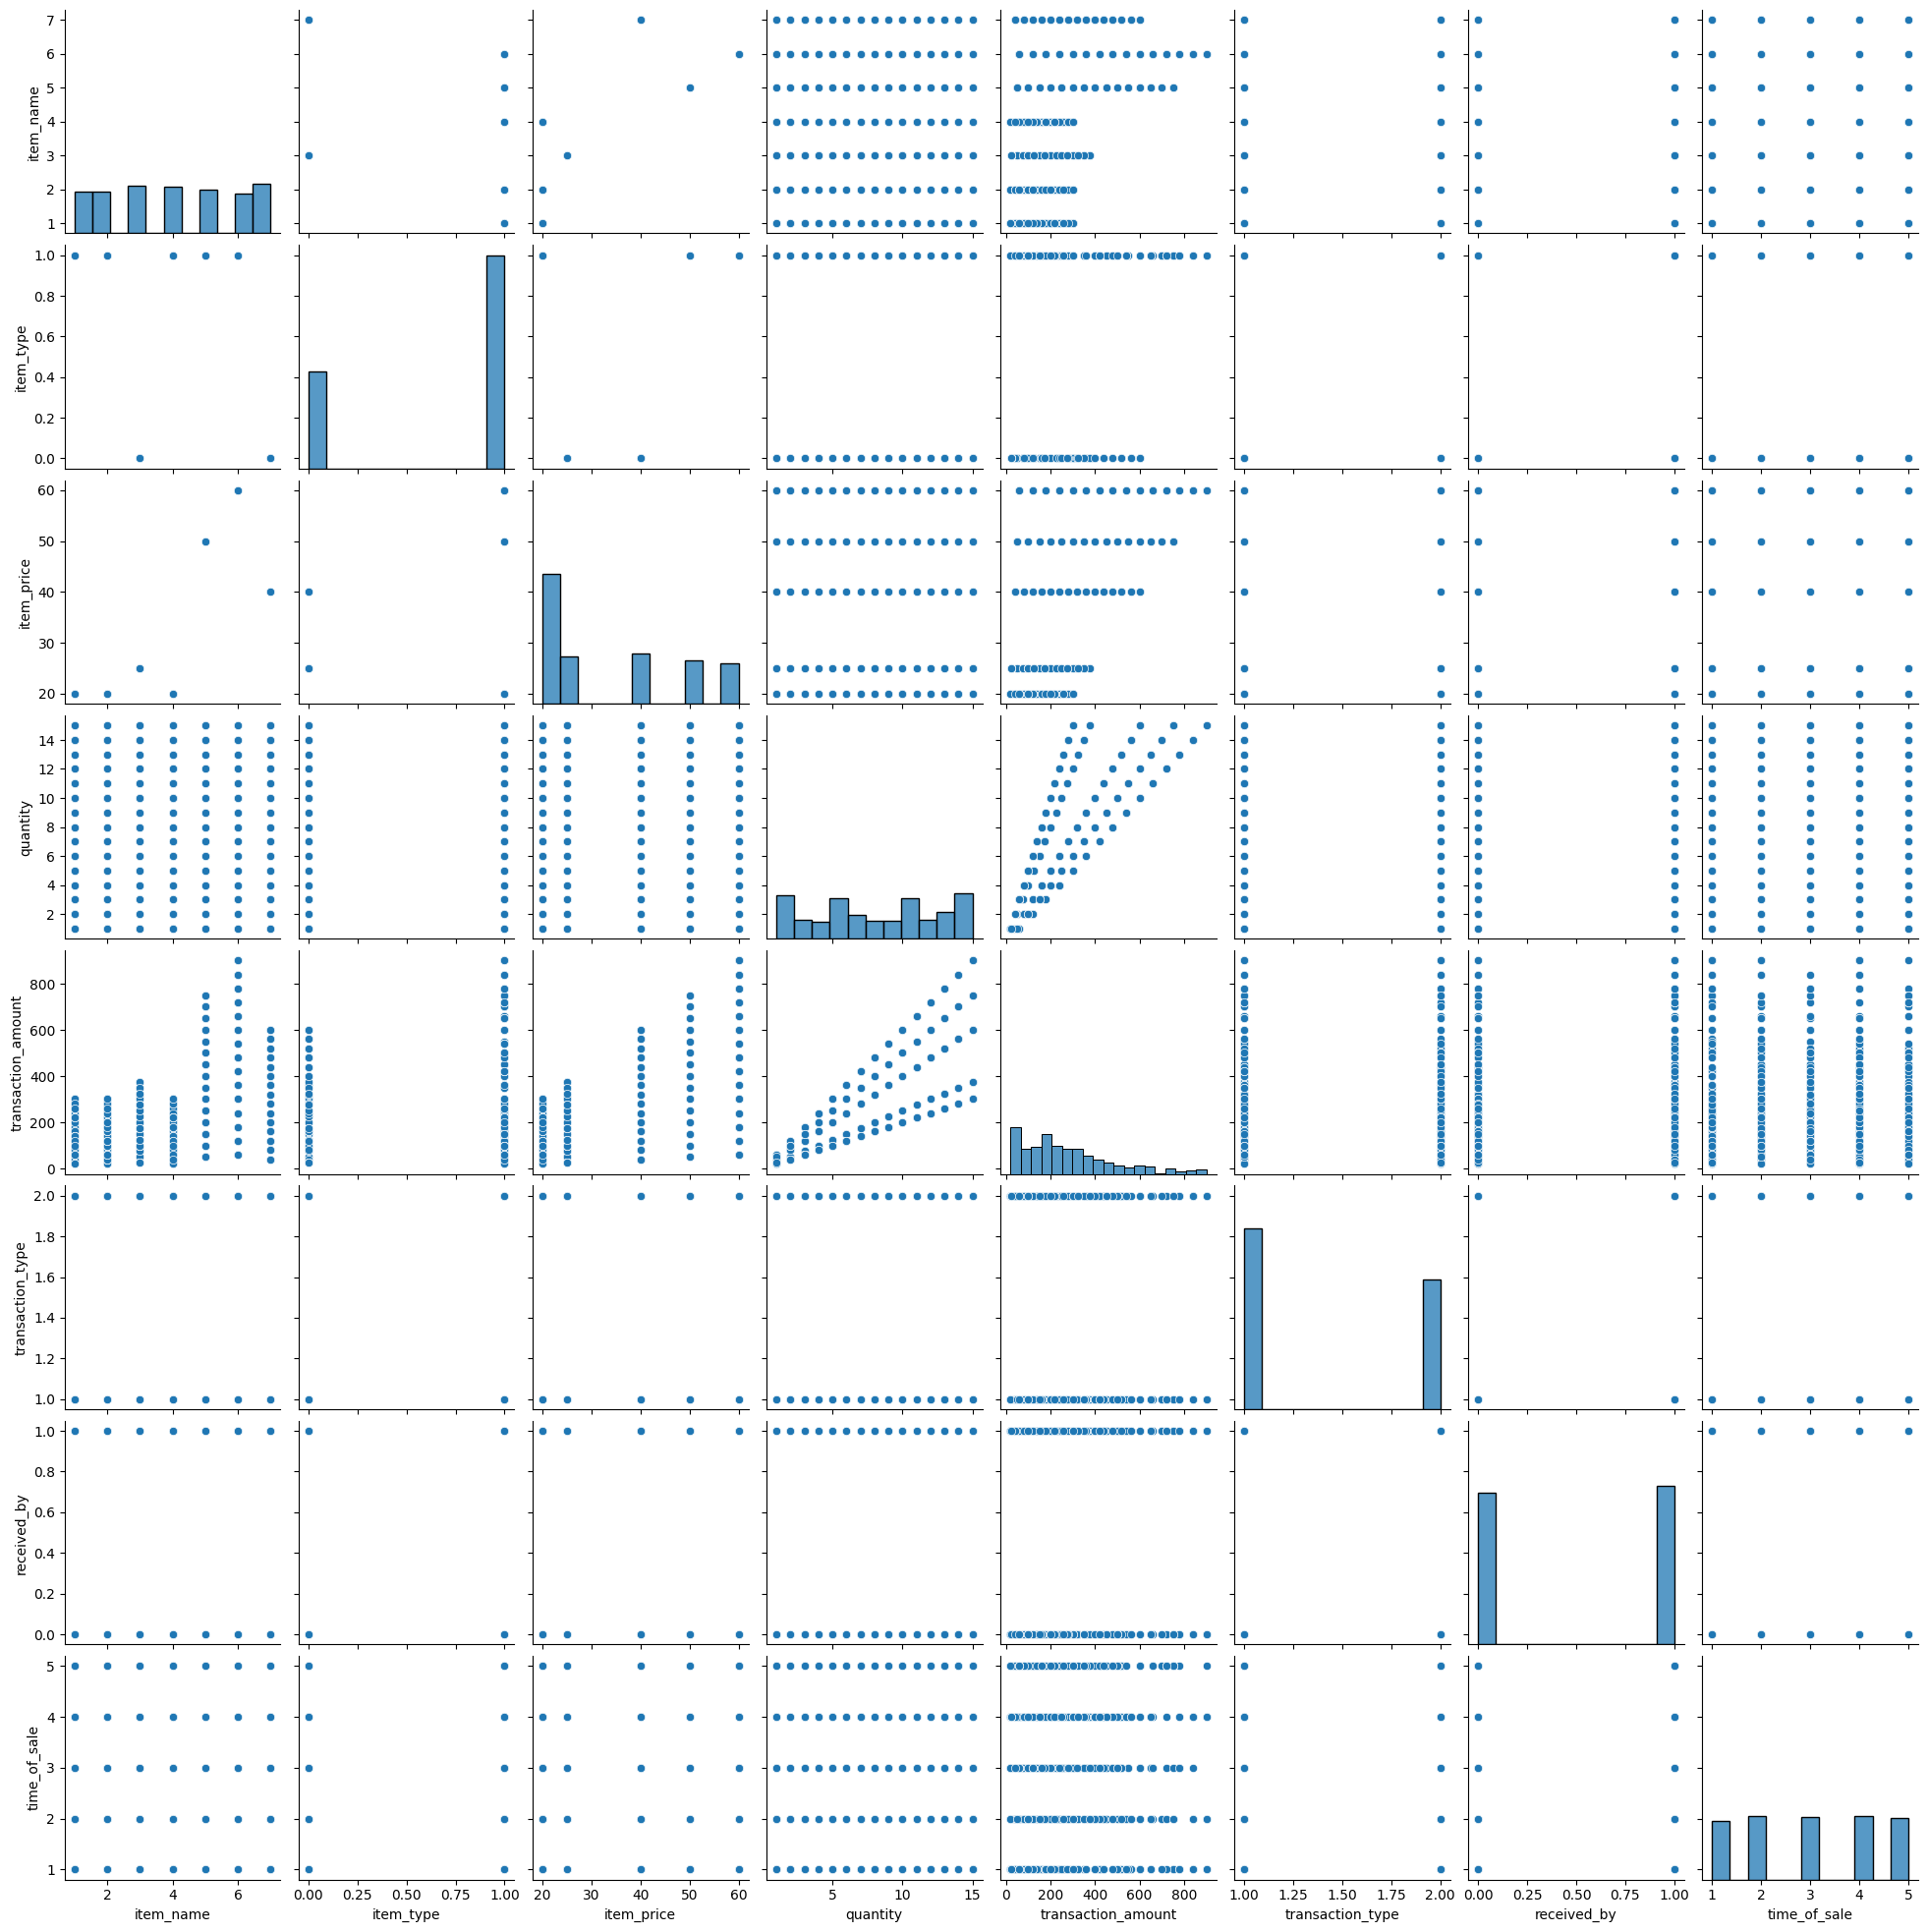

In [60]:
sns.pairplot(data=df)

In [ ]:
sns.scatterplot
sns.kdeplot
sns.barplot
sns.boxplot
sns.distplot
sns.lineplot
sns.pairplot

In [61]:
df.to_csv('clean_sales.csv',index=False)